In [2]:
#!/usr/bin/env python3
# -*- coding: utf-8 -*-
import sys
import os
import glob
from pathlib import Path
import numpy as np
import pandas as pd
import dask.dataframe as dd
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker  # Import minor locator ticker
import matplotlib.colors as mcolors
from matplotlib.colors import LinearSegmentedColormap
import matplotlib.patches as patches
from re import split
from matplotlib.backends.backend_pdf import PdfPages
from scipy.stats import skew
import matplotlib.image as mpimg

from scipy import stats
from scipy.stats import norm, gamma, logistic, t, lognorm, expon, betaprime
# from scipy.special import gamma

from scipy.optimize import curve_fit

import calendar

# from dask_jobqueue import SLURMCluster

# from dask.distributed import Client, progress
from IPython.display import Image
from dask.distributed import Client
import folium

import warnings

warnings.filterwarnings('ignore')

import seaborn as sns
# import hvplot.xarray

import Functions as Func

In [125]:
# 🌧️ Instrument name
station_name = "Montañita_San_Antonio"

PROJECT_ROOT = Path.cwd().parent
DATA_PATH = PROJECT_ROOT / "data" / "resultados" / "Zarr"
FIG_PATH = PROJECT_ROOT / "figures"

instrument_path = FIG_PATH / station_name

instrument_path.mkdir(parents=True, exist_ok=True)


ds_JPC = xr.open_zarr(
    DATA_PATH / "425_filtrado_plot.zarr"
)

# Filter
ds_JPC = ds_JPC.dropna(dim="time", subset=["lwc_filt"])

ds_JPC

<xarray.Dataset> Size: 752MB
Dimensions:       (time: 102459, diameter: 22, velocity: 20)
Coordinates:
  * time          (time) datetime64[ns] 820kB 2020-02-14T03:47:00 ... 2025-04...
  * diameter      (diameter) float64 176B 0.125 0.25 0.375 0.5 ... 7.0 7.5 8.0
  * velocity      (velocity) float64 160B 0.1 0.2 0.4 0.6 ... 7.4 8.2 9.0 10.0
Data variables: (12/19)
    Client        (time) <U1 410kB dask.array<chunksize=(9979,), meta=np.ndarray>
    MOR           (time) float64 820kB dask.array<chunksize=(9979,), meta=np.ndarray>
    Synop_Code    (time) <U1 410kB dask.array<chunksize=(9979,), meta=np.ndarray>
    d_m_filt      (time) float64 820kB dask.array<chunksize=(9979,), meta=np.ndarray>
    lwc_filt      (time) float64 820kB dask.array<chunksize=(9979,), meta=np.ndarray>
    n_t           (time) float64 820kB dask.array<chunksize=(9979,), meta=np.ndarray>
    ...            ...
    raw_filtrada  (time, diameter, velocity) float64 361MB dask.array<chunksize=(9979, 22, 20), meta=np.ndarray>
    ref           (time) float64 820kB dask.array<chunksize=(9979,), meta=np.ndarray>
    ref_filt      (time) float64 820kB dask.array<chunksize=(9979,), meta=np.ndarray>
    rl_int        (time) float64 820kB dask.array<chunksize=(9979,), meta=np.ndarray>
    rs_int        (time) float64 820kB dask.array<chunksize=(9979,), meta=np.ndarray>
    vd            (diameter) float64 176B dask.array<chunksize=(22,), meta=np.ndarray>
Attributes:
    institution:  SIATA / Universidad del Quindío
    references:   {'[1]': 'https://doi.org/10.1175/JTECH-D-13-00174.1', '[2]'...
    title:        Thies Disdrometer Precipitation Dataset

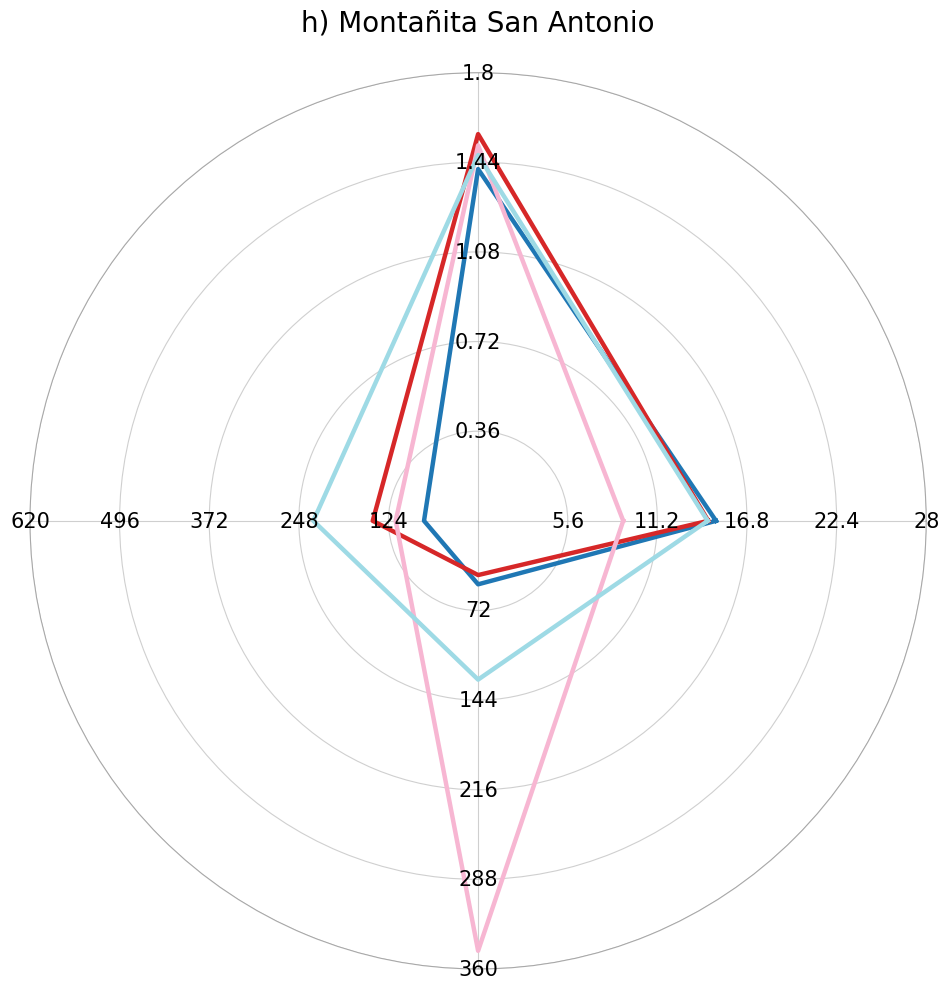

In [128]:
# =========================================================
# 🌧️ Months to compare
# =========================================================

# months = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]
months = [1, 4, 7, 10]

# =========================================================
# 📊 Radar labels
# =========================================================

labels = [
    r'STD$(R)$',
    r'$\langle D_m \rangle$',
    r'$R_{acc}$',
    r'$\langle M \rangle$'
]

# =========================================================
# 📊 Physical ranges for each variable
# =========================================================

ranges = [
    (0, 28),     # STD(R)
    (0, 1.8),    # Dm
    (0, 620),      # R_acc
    (0, 360)     # Duration
]

# =========================================================
# 📊 Tick labels for each axis
# =========================================================

tick_labels = [
    [5.6, 11.2, 16.8, 22.4, 28],      # STD(R)
    [0.36, 0.72, 1.08, 1.44, 1.80],      # Dm
    [124, 248, 372, 496, 620],      # R_acc
    [72, 144, 216, 288, 360]         # Duration
]

# =========================================================
# 📐 Angles
# =========================================================

angles = np.linspace(
    0,
    2*np.pi,
    len(labels),
    endpoint=False
)

angles = np.append(angles, angles[0])

# =========================================================
# 📊 Store all months
# =========================================================

all_scaled = []
month_labels = []

# =========================================================
# 🌧️ Loop through months
# =========================================================

for month in months:

    # =====================================================
    # 🌧️ Select month
    # =====================================================

    ds_month = ds_JPC.where(
        ds_JPC.time.dt.month == month,
        drop=True
    )

    # =====================================================
    # 📊 STD Rain Rate
    # =====================================================

    std_r = ds_month.r_int_filt.std().values

    # =====================================================
    # 📊 Mean Dm
    # =====================================================

    mean_dm = ds_month.d_m_filt.mean().values

    # =====================================================
    # 🌧️ Monthly rainfall accumulation climatology
    # =====================================================

    # Convert rain rate [mm/h]
    # to rain depth per minute [mm]
    rain_per_sample = ds_month.r_int_filt / 60

    # Convert to pandas series
    rain_series = rain_per_sample.to_series()

    # Monthly accumulation for each month-year
    monthly_acc = rain_series.resample('ME').sum(min_count=1)

    # Climatological mean monthly accumulation
    rain_acc = monthly_acc.mean()

    # =====================================================
    # 🌧️ Mean event duration
    # =====================================================

    start, end = Func.get_events(ds_month)

    durations = [
        (e - s) / np.timedelta64(1, 'm')
        for s, e in zip(start, end)
    ]

    mean_duration = np.mean(durations)

    # =====================================================
    # 📊 Variable vector
    # =====================================================

    values = np.array([
        std_r,
        mean_dm,
        rain_acc,
        mean_duration
    ])

    # =====================================================
    # 🔄 Normalize for radar geometry
    # =====================================================

    scaled = []

    for val, (vmin, vmax) in zip(values, ranges):

        norm_val = (val - vmin) / (vmax - vmin)

        # Force maximum radius
        norm_val = np.clip(norm_val, 0, 1)

        scaled.append(norm_val)

    # Close polygon
    scaled.append(scaled[0])

    # Store
    all_scaled.append(scaled)

    month_labels.append(month)

# =========================================================
# 🕸️ Create radar plot
# =========================================================

fig, ax = plt.subplots(
    figsize=(10, 10),
    subplot_kw=dict(polar=True)
)

# =========================================================
# 📊 Grid circles
# =========================================================

grid_levels = np.linspace(0.2, 1.0, 5)

ax.set_yticks(grid_levels)

ax.set_yticklabels([])

# =========================================================
# 📏 Force fixed radar radius
# =========================================================

ax.set_ylim(0, 1)

# =========================================================
# 📊 Plot all months
# =========================================================

month_names = {
    1: 'Jan',
    2: 'Feb',
    3: 'Mar',
    4: 'Apr',
    5: 'May',
    6: 'Jun',
    7: 'Jul',
    8: 'Aug',
    9: 'Sep',
    10: 'Oct',
    11: 'Nov',
    12: 'Dec'
}

# =========================================================
# 🎨 Custom colors
# =========================================================

colors = plt.cm.tab20(
    np.linspace(0, 1, len(months))
)

# colors = [
#     '#E69F00',  # DEF
#     '#0072B2',  # MAM
#     '#009E73',  # JJA
#     '#CC79A7',   # SON
# ]

for scaled, month in zip(all_scaled, month_labels):

    ax.plot(
    angles,
    scaled,
    linewidth=3.2,
    color=colors[month_labels.index(month)],
    label=month_names[month]
)

    ax.fill(
    angles,
    scaled,
    color=colors[month_labels.index(month)],
    alpha=0
)

# =========================================================
# 📊 Axis labels
# =========================================================

# ax.set_xticks(angles[:-1])

# ax.set_xticklabels(
#     labels,
#     fontsize=17
# )

ax.set_xticks(angles[:-1])

ax.set_xticklabels([])

# =========================================================
# 📌 Improve label positions
# =========================================================

for label, angle in zip(ax.get_xticklabels(), angles[:-1]):

    # Right
    if angle == 0:
        label.set_horizontalalignment('left')

    # Left
    elif angle == np.pi:
        label.set_horizontalalignment('right')

    # Top
    elif angle == np.pi / 2:
        label.set_verticalalignment('bottom')

    # Bottom
    elif angle == 3 * np.pi / 2:
        label.set_verticalalignment('top')

# =========================================================
# 📊 Add physical scales
# =========================================================

for angle, ticks in zip(
    angles[:-1],
    tick_labels
):

    for r, tick in zip(grid_levels, ticks):

        ax.text(
            angle,
            r,
            str(tick),
            fontsize=15,
            ha='center',
            va='center',
            color='black',
            alpha=1
        )

# =========================================================
# 📌 Title
# =========================================================

ax.set_title(
    f'h) {station_name.replace("_", " ")}',
    fontsize=20,
    pad=30
)

# =========================================================
# 📊 Legend
# =========================================================

# ax.legend(
#     loc='upper right',
#     bbox_to_anchor=(1.2, 1.1),
#     fontsize=15
# )

ax.grid(alpha=0.6)

ax.spines['polar'].set_color('gray')
ax.spines['polar'].set_alpha(0.6)

plt.tight_layout()

# 💾 Save figure
# plt.savefig(
#     instrument_path / f"{station_name}_Spyder_Final.png",
#     dpi=300,
#     bbox_inches='tight'
# )

# 💾 Save figure
plt.savefig(
    instrument_path / f"{station_name}_Spyder_Season_Final.png",
    dpi=300,
    bbox_inches='tight'
)

plt.show()

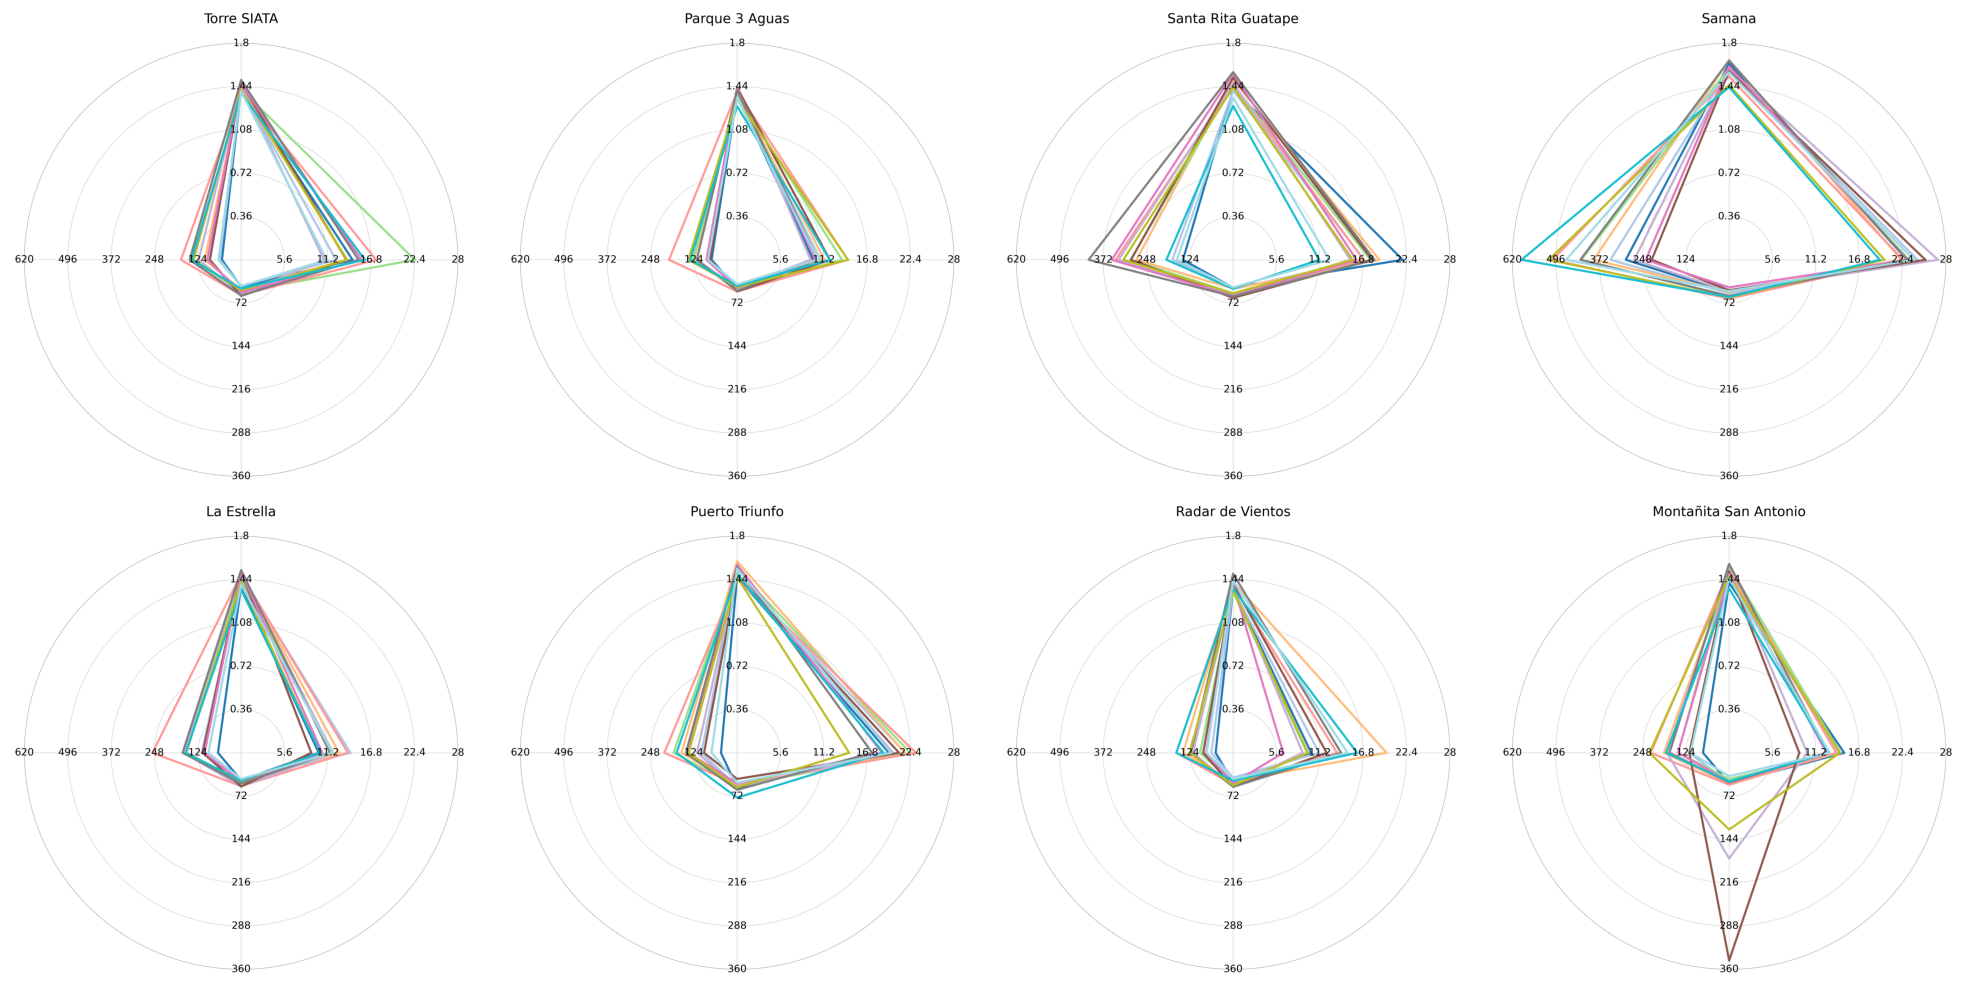

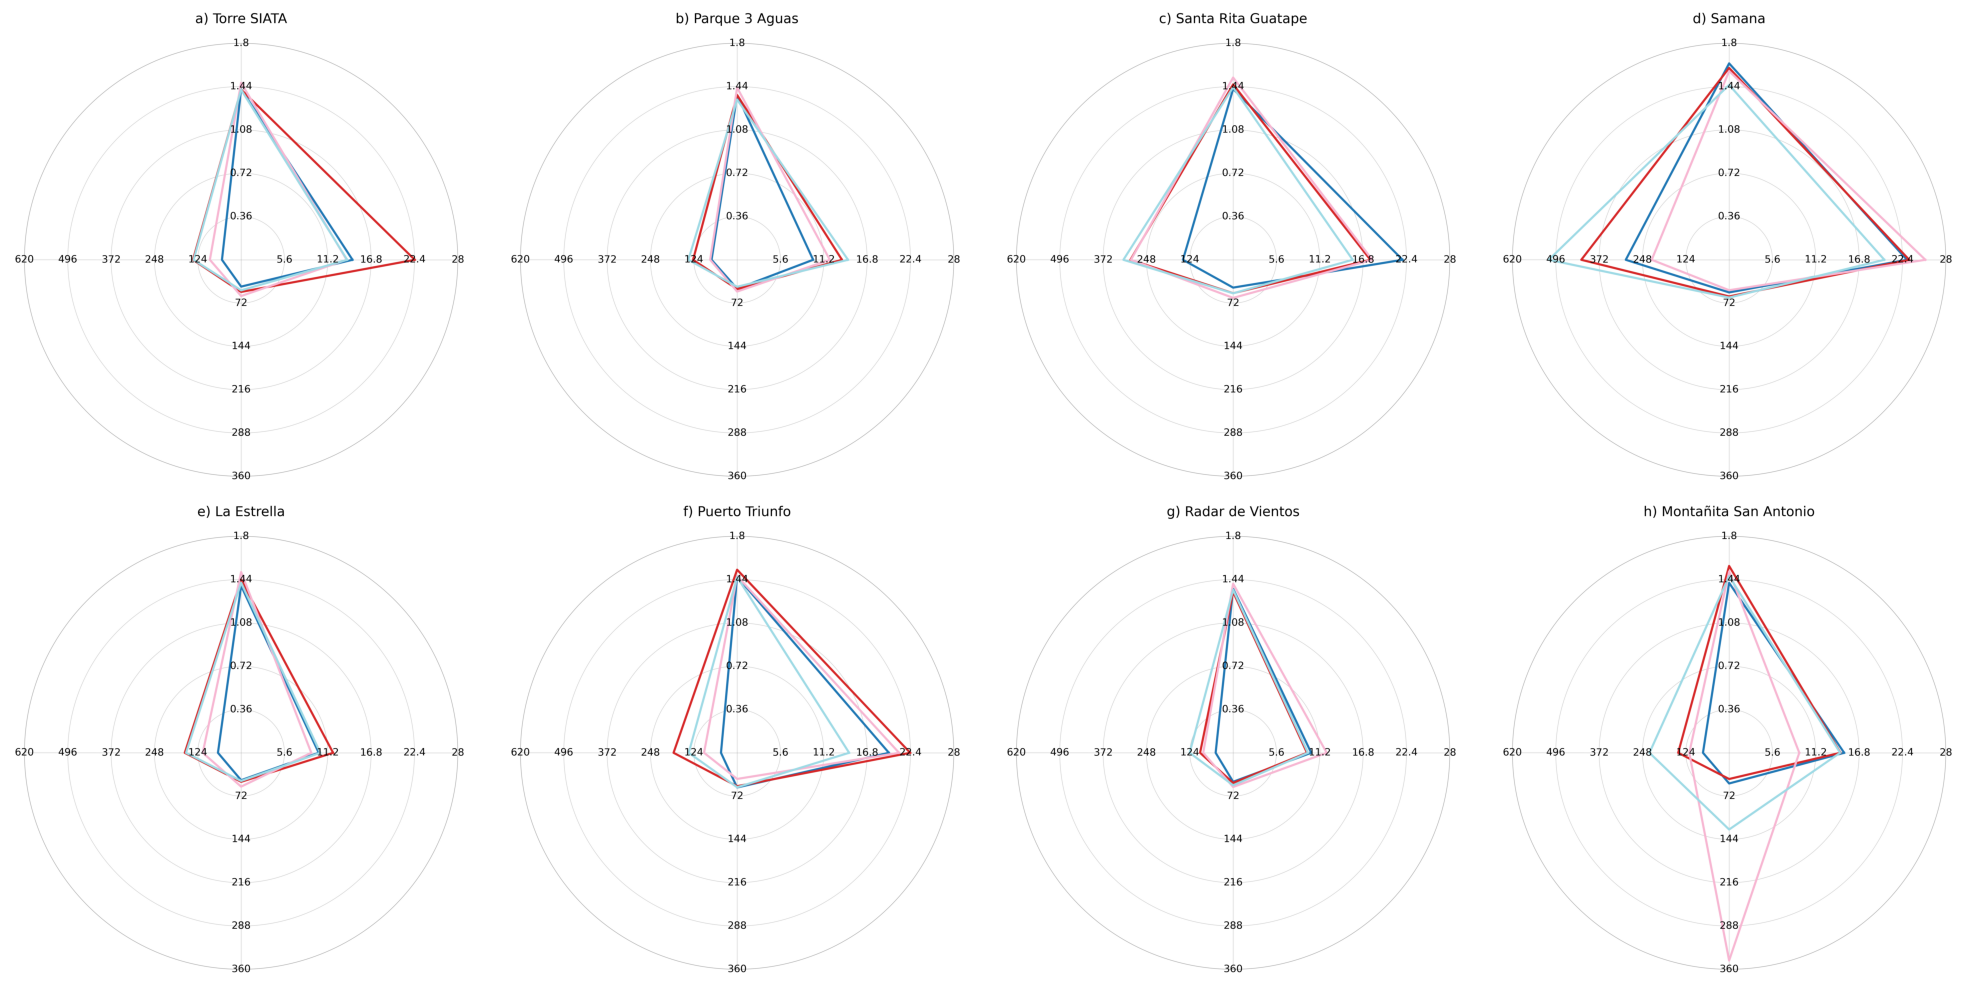

In [130]:
# =========================================================
# 📌 Desired order
# =========================================================

desired_order = [
    "Torre_SIATA",
    "Parque_3_Aguas",
    "Santa_Rita_Guatape",
    "Samana",
    "La_Estrella",
    "Puerto_Triunfo",
    "Radar_de_Vientos",
    "Montañita_San_Antonio"
]

# =========================================================
# 🖼️ Search all Spyder figures
# =========================================================

# Monthly Spyder
spyder_files = sorted(
    FIG_PATH.glob("*/**/*Spyder_Final.png")
)

spyder_files = sorted(
    spyder_files,
    key=lambda x: desired_order.index(
        x.stem.replace("_Spyder_Final", "")
    )
)

# Seasonal Spyder
season_files = sorted(
    FIG_PATH.glob("*/**/*Spyder_Season_Final.png")
)

season_files = sorted(
    season_files,
    key=lambda x: desired_order.index(
        x.stem.replace("_Spyder_Season_Final", "")
    )
)

# =========================================================
# 📊 Function to create matrix
# =========================================================

def create_matrix(image_files, save_name, nrows=2, ncols=4):

    # Create figure
    fig, axs = plt.subplots(
        nrows,
        ncols,
        figsize=(20, 10)
    )

    # Flatten axes
    axs = axs.flatten()

    # =====================================================
    # 🔄 Loop through images
    # =====================================================

    for ax, file in zip(axs, image_files):

        # Read image
        img = mpimg.imread(file)

        # Plot
        ax.imshow(img)

        # Remove axes
        ax.axis('off')

    # =====================================================
    # ❌ Remove empty panels
    # =====================================================

    for ax in axs[len(image_files):]:
        ax.axis('off')

    # =====================================================
    # 📐 Layout
    # =====================================================

    plt.tight_layout()

    # =====================================================
    # 💾 Save matrix
    # =====================================================

    plt.savefig(
        FIG_PATH / save_name,
        dpi=300,
        bbox_inches='tight'
    )

    # =====================================================
    # 👀 Show figure
    # =====================================================

    plt.show()

# =========================================================
# 🌧️ Monthly Spyder Matrix
# =========================================================

create_matrix(
    spyder_files,
    save_name="Monthly_Spyder_Matrix_Final.png",
    nrows=2,
    ncols=4
)

# =========================================================
# 🌦️ Seasonal Spyder Matrix
# =========================================================

create_matrix(
    season_files,
    save_name="Seasonal_Spyder_Matrix_Final.png",
    nrows=2,
    ncols=4
)

### With terminal Velocity

```python
# =========================================================
# 🌧️ Months to compare
# =========================================================

months = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]
# months = [1, 4, 7, 10]

# =========================================================
# 📊 Radar labels
# =========================================================

labels = [
    r'STD$(R)$',
    r'$\langle D_m \rangle$',
    r'$\langle V_t \rangle$',
    r'$\langle M \rangle$'
]

# =========================================================
# 📊 Physical ranges for each variable
# =========================================================

ranges = [
    (0, 7),     # STD(R)
    (0, 1.4),    # Dm
    (0, 3),      # Vt
    (0, 190)     # Duration
]

# =========================================================
# 📊 Tick labels for each axis
# =========================================================

tick_labels = [
    [1.4, 2.8, 4.2, 5.6, 7],      # STD(R)
    [0.28, 0.56, 0.84, 1.12, 1.4],      # Dm
    [0.6, 1.2, 1.8, 2.4, 3],      # Vt
    [38, 76, 114, 152, 190]         # Duration
]

# =========================================================
# 📐 Angles
# =========================================================

angles = np.linspace(
    0,
    2*np.pi,
    len(labels),
    endpoint=False
)

angles = np.append(angles, angles[0])

# =========================================================
# 📊 Store all months
# =========================================================

all_scaled = []
month_labels = []

# =========================================================
# 🌧️ Loop through months
# =========================================================

for month in months:

    # =====================================================
    # 🌧️ Select month
    # =====================================================

    ds_month = ds_JPC.where(
        ds_JPC.time.dt.month == month,
        drop=True
    )

    # =====================================================
    # 📊 STD Rain Rate
    # =====================================================

    std_r = ds_month.r_int_filt.std().values

    # =====================================================
    # 📊 Mean Dm
    # =====================================================

    mean_dm = ds_month.d_m_filt.mean().values

    # =====================================================
    # 🌧️ Mean terminal velocity
    # =====================================================

    delta_D = ds_month.diameter.diff("diameter")

    delta_D = xr.concat(
        [ds_month.diameter[0], delta_D],
        dim="diameter"
    )

    mean_v = (
        (ds_month.vd * ds_month.nd_filt * delta_D)
        .sum(dim=["time", "diameter"])
        /
        (ds_month.nd_filt * delta_D)
        .sum(dim=["time", "diameter"])
    ).values

    # =====================================================
    # 🌧️ Mean event duration
    # =====================================================

    start, end = Func.get_events(ds_month)

    durations = [
        (e - s) / np.timedelta64(1, 'm')
        for s, e in zip(start, end)
    ]

    mean_duration = np.mean(durations)

    # =====================================================
    # 📊 Variable vector
    # =====================================================

    values = np.array([
        std_r,
        mean_dm,
        mean_v,
        mean_duration
    ])

    # =====================================================
    # 🔄 Normalize for radar geometry
    # =====================================================

    scaled = []

    for val, (vmin, vmax) in zip(values, ranges):

        norm_val = (val - vmin) / (vmax - vmin)

        # Force maximum radius
        norm_val = np.clip(norm_val, 0, 1)

        scaled.append(norm_val)

    # Close polygon
    scaled.append(scaled[0])

    # Store
    all_scaled.append(scaled)

    month_labels.append(month)

# =========================================================
# 🕸️ Create radar plot
# =========================================================

fig, ax = plt.subplots(
    figsize=(10, 10),
    subplot_kw=dict(polar=True)
)

# =========================================================
# 📊 Grid circles
# =========================================================

grid_levels = np.linspace(0.2, 1.0, 5)

ax.set_yticks(grid_levels)

ax.set_yticklabels([])

# =========================================================
# 📏 Force fixed radar radius
# =========================================================

ax.set_ylim(0, 1)

# =========================================================
# 📊 Plot all months
# =========================================================

month_names = {
    1: 'Jan',
    2: 'Feb',
    3: 'Mar',
    4: 'Apr',
    5: 'May',
    6: 'Jun',
    7: 'Jul',
    8: 'Aug',
    9: 'Sep',
    10: 'Oct',
    11: 'Nov',
    12: 'Dec'
}

# =========================================================
# 🎨 Custom colors
# =========================================================

colors = plt.cm.tab20(
    np.linspace(0, 1, len(months))
)

for scaled, month in zip(all_scaled, month_labels):

    ax.plot(
    angles,
    scaled,
    linewidth=2,
    color=colors[month_labels.index(month)],
    label=month_names[month]
)

    ax.fill(
    angles,
    scaled,
    color=colors[month_labels.index(month)],
    alpha=0.10
)

# =========================================================
# 📊 Axis labels
# =========================================================

ax.set_xticks(angles[:-1])

ax.set_xticklabels(
    labels,
    fontsize=16
)

# =========================================================
# 📌 Improve label positions
# =========================================================

for label, angle in zip(ax.get_xticklabels(), angles[:-1]):

    # Right
    if angle == 0:
        label.set_horizontalalignment('left')

    # Left
    elif angle == np.pi:
        label.set_horizontalalignment('right')

    # Top
    elif angle == np.pi / 2:
        label.set_verticalalignment('bottom')

    # Bottom
    elif angle == 3 * np.pi / 2:
        label.set_verticalalignment('top')

# =========================================================
# 📊 Add physical scales
# =========================================================

for angle, ticks in zip(
    angles[:-1],
    tick_labels
):

    for r, tick in zip(grid_levels, ticks):

        ax.text(
            angle,
            r,
            str(tick),
            fontsize=12,
            ha='center',
            va='center',
            color='black',
            alpha=1
        )

# =========================================================
# 📌 Title
# =========================================================

ax.set_title(
    f'{station_name.replace("_", " ")}',
    fontsize=14,
    pad=30
)

# =========================================================
# 📊 Legend
# =========================================================

ax.legend(
    loc='upper right',
    bbox_to_anchor=(1.2, 1.1),
    fontsize=14
)

ax.grid(alpha=0.5)

ax.spines['polar'].set_linewidth(1.5)

plt.tight_layout()

# 💾 Save figure
plt.savefig(
    instrument_path / f"{station_name}_Spyder.png",
    dpi=300,
    bbox_inches='tight'
)

plt.show()
```